In [5]:
!pip install lime

In [6]:
import re
import string
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from lime.lime_text import LimeTextExplainer

# -----------------------------
# Config
# -----------------------------
MODEL_NAME = "cirimus/modernbert-base-go-emotions"
PLEX_CKPT = "plex_seismic_modernbert_lime.pth"   # your trained head
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
LAYER_IDX = -1   # use last layer; if you rebuilt features with layer 9, set to 9

# GoEmotions label names (28)
GOEMO_LABELS = [
    'admiration','amusement','anger','annoyance','approval','caring','confusion','curiosity',
    'desire','disappointment','disapproval','disgust','embarrassment','excitement','fear',
    'gratitude','grief','joy','love','nervousness','optimism','pride','realization','relief',
    'remorse','sadness','surprise','neutral'
]

# -----------------------------
# Utils
# -----------------------------
def normalize_token(s: str) -> str:
    s = s.lower()
    s = s.translate(str.maketrans("", "", string.punctuation))
    return re.sub(r"\s+", " ", s).strip()

def plot_word_importances(words, scores, title, words_per_row=8, fontsize=13):
    if len(words) == 0:
        print(f"[{title}] No words to display.")
        return
    scores = np.asarray(scores, dtype=float)
    m = np.max(np.abs(scores)) if scores.size else 1.0
    s = scores / (m + 1e-8)
    cmap_neg = plt.get_cmap("Blues")
    cmap_pos = plt.get_cmap("Reds")

    plt.figure(figsize=(12, 2.4))
    x, y = 0.0, 0.8
    for i, (w, v) in enumerate(zip(words, s)):
        color = cmap_pos(v) if v >= 0 else cmap_neg(-v)
        plt.text(x, y, w, fontsize=fontsize, ha='left', va='center', color='black',
                 bbox=dict(facecolor=color, edgecolor='none', boxstyle='round,pad=0.3'))
        x += (len(w) * 0.012) + 0.05
        if (i + 1) % words_per_row == 0:
            x = 0.0
            y -= 0.25
    plt.title(title)
    plt.axis('off')
    plt.show()

# -----------------------------
# Model: ModernBERT
# -----------------------------
tok = AutoTokenizer.from_pretrained(MODEL_NAME)
clf = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME).to(DEVICE).eval()

@torch.no_grad()
def model_probs(texts):
    enc = tok(texts, return_tensors="pt", truncation=True, padding=True, max_length=256).to(DEVICE)
    logits = clf(**enc).logits
    probs = torch.sigmoid(logits)  # multi-label
    return probs.cpu().numpy()     # [B, 28]

def top_pred_idx(text):
    return int(np.argmax(model_probs([text])[0]))

# -----------------------------
# PLEX head (SeismicNet shared)
# -----------------------------
class SeismicNet(nn.Module):
    def __init__(self, input_size):
        super().__init__()
        self.fc1 = nn.Linear(input_size, 128)
        self.fc2 = nn.Linear(128, 64)
        self.dropout = nn.Dropout(p=0.5)
    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

class PLEXHeadShared(nn.Module):
    def __init__(self, input_size=768):
        super().__init__()
        self.net = SeismicNet(input_size)
    def forward(self, cls_emb: torch.Tensor, word_embs: torch.Tensor) -> torch.Tensor:
        # repeat CLS per word if needed
        if cls_emb.dim() == 1:
            cls_emb = cls_emb.unsqueeze(0).repeat(word_embs.shape[0], 1)
        cls_proj  = self.net(cls_emb)       # [W, 64]
        word_proj = self.net(word_embs)     # [W, 64]
        # centering helps dispersion
        word_proj = word_proj - word_proj.mean(dim=0, keepdim=True)
        cls_norm  = F.normalize(cls_proj, dim=-1)
        word_norm = F.normalize(word_proj, dim=-1)
        sims = (cls_norm * word_norm).sum(dim=-1)  # [W]
        return sims

# Load PLEX
plex = PLEXHeadShared(input_size=768).to(DEVICE).eval()
state = torch.load(PLEX_CKPT, map_location="cpu", weights_only=False)
sd = state.get("state_dict", state)
# If saved bare, try remap
if isinstance(sd, dict) and all(k.split(".")[0] in {"net","fc1","fc2"} for k in sd.keys()):
    sd = { (f"net.{k}" if k.startswith(("fc1","fc2")) else k): v for k,v in sd.items() }
missing, unexpected = plex.load_state_dict(sd, strict=False)
print("PLEX load -> missing:", missing)
print("PLEX load -> unexpected:", unexpected)

# -----------------------------
# Embedding extractor with subword->word merge
# -----------------------------
@torch.no_grad()
def get_cls_and_word_embs(text, layer_idx=LAYER_IDX):
    # pass 1: get real tokenized length
    enc0 = tok(text, return_tensors="pt", truncation=False, padding=False, return_offsets_mapping=True)
    seq_len = enc0["input_ids"].shape[1]
    # pass 2: fix max_length to seq_len (no truncation warning), keep offsets
    enc = tok(text, return_tensors="pt", truncation=True, max_length=seq_len,
              padding=False, return_offsets_mapping=True)
    offsets = enc["offset_mapping"][0].tolist()
    enc = {k: v.to(DEVICE) for k, v in enc.items()}

    out = clf(**{k:v for k,v in enc.items() if k in ["input_ids","attention_mask"]},
              output_hidden_states=True)
    hidden = out.hidden_states[layer_idx].squeeze(0)  # [T, H]
    cls_embedding = hidden[0].detach().cpu()          # [H]

    # collect subwords (skip [CLS]/[SEP], zero-length offsets)
    sub_spans = []
    for i, (s, e) in enumerate(offsets):
        if i == 0 or i == len(offsets) - 1 or s == e:
            continue
        sub_spans.append(((s, e), hidden[i].detach().cpu()))

    # whitespace words with char spans
    words = text.split()
    word_emb_list = []
    words_char_spans = []
    char_ptr = 0
    for w in words:
        w_start = text.find(w, char_ptr)
        if w_start == -1:
            w_start = char_ptr
        w_end = w_start + len(w)
        words_char_spans.append((w_start, w_end, w))
        char_ptr = w_end

    for (w_start, w_end, w) in words_char_spans:
        embs = [emb for (s, e), emb in sub_spans if not (e <= w_start or s >= w_end)]
        if len(embs) == 0:
            # relaxed fallback: substring match
            embs = [emb for (s, e), emb in sub_spans if (text[s:e] in w) or (w in text[s:e])]
        if len(embs) > 0:
            word_emb_list.append(torch.stack(embs, dim=0).mean(dim=0))
    word_embs = torch.stack(word_emb_list, dim=0) if len(word_emb_list) > 0 else torch.empty(0, hidden.shape[-1])
    return cls_embedding, words, word_embs

# -----------------------------
# LIME: prediction fn and alignment
# -----------------------------
def predict_proba(texts):
    # returns [B, 28]
    return model_probs(texts)

explainer = LimeTextExplainer(class_names=GOEMO_LABELS)

def lime_aligned_scores(text, words, target_idx, num_features=None):
    # run LIME
    if num_features is None:
        num_features = min(max(len(words), 5), 20)
    exp = explainer.explain_instance(text, predict_proba, labels=[target_idx], num_features=num_features)
    pairs = exp.as_list(label=target_idx)  # list[(token_str, weight)]
    lime_tokens = [t for t,_ in pairs]
    lime_scores = [float(w) for _,w in pairs]

    # align to whitespace words
    norm_words = [normalize_token(w) for w in words]
    idxs = {}
    for j, w in enumerate(norm_words):
        if w:
            idxs.setdefault(w, []).append(j)

    aligned = np.zeros(len(words), dtype=float)
    for tok, wt in zip(lime_tokens, lime_scores):
        key = normalize_token(tok)
        if key in idxs:
            share = wt / max(1, len(idxs[key]))
            for j in idxs[key]:
                aligned[j] += share
    return np.array(aligned, dtype=float)

# -----------------------------
# Driver: test sentences
# -----------------------------
def explain_sentence(text):
    print("\n" + "="*80)
    print("Text:", text)
    # prediction
    probs = model_probs([text])[0]
    tidx = int(np.argmax(probs))
    print(f"Predicted: {GOEMO_LABELS[tidx]} ({probs[tidx]:.2f})")

    # embeddings & words
    cls, words, word_embs = get_cls_and_word_embs(text, layer_idx=LAYER_IDX)
    if word_embs.numel() == 0 or len(words) == 0:
        print("No word embeddings found; skipping.")
        return

    # PLEX scores
    with torch.no_grad():
        plex_scores = plex(cls.to(DEVICE), word_embs.to(DEVICE)).cpu().numpy()

    # LIME aligned
    lime_scores_al = lime_aligned_scores(text, words, target_idx=tidx)

    # plots
    plot_word_importances(words, plex_scores, title="PLEX — word importances")
    plot_word_importances(words, lime_scores_al, title="LIME (aligned) — word importances")

PLEX load -> missing: []
PLEX load -> unexpected: []



Text: Absolutely thrilled with the team’s results today—genuinely grateful for everyone’s late-night hustle and brilliant ideas; this kind of momentum makes me optimistic about the roadmap and ridiculously excited for what we’ll ship next.
Predicted: excitement (0.92)


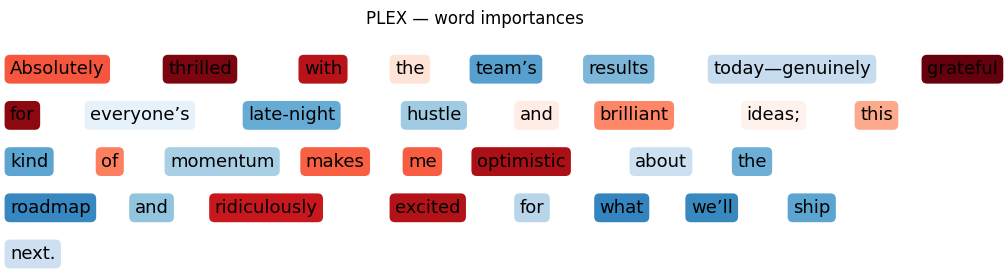

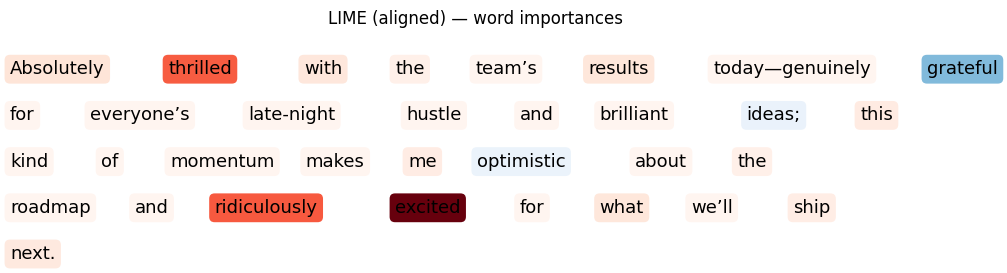

In [8]:
if __name__ == "__main__":
    sentences = [
        "Absolutely thrilled with the team’s results today—genuinely grateful for everyone’s late-night hustle and brilliant ideas; this kind of momentum makes me optimistic about the roadmap and ridiculously excited for what we’ll ship next.",
    ]
    for s in sentences:
        explain_sentence(s)
